In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper


sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [26]:

event_name = 'SleepBaseline'
# event_name = 'PassiveForward'

session = sessions[3]

print(session)

lfp, srate = hc18_bf.load_lfp_hc18_data(session)

event_times, event_descriptions = hc18_bf.get_events(session, event_name)

event_times = np.sort(np.array(event_times))
event_start = np.nanmin(event_times)
event_end = np.nanmax(event_times)

event_start = event_times[0]
event_end = event_times[1]

shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)

file_path = f'{data_path}/{session}/'
filename = f'{session}_{event_name}_sws_epoch'
sleep_epochs = np.load(filename)

# lfp = sig.detrend(helper.eegfilt(lfp[:,sleep_epochs],srate,1,0))
# lfp = sig.detrend(helper.eegfilt(lfp[:,sleep_epochs],srate,1,0))

time_vector = np.linspace(0,lfp.shape[1]/srate,lfp.shape[1])
# sleep_epoch = (time_vector >= event_start) & (time_vector <= event_end)
# lfp = lfp[:,sleep_epoch]
# time_vector = time_vector[sleep_epoch]


Train-292-20150501


In [31]:
time_vector[sleep_epochs].shape[0]/srate

45439.0

In [34]:
sleep_epochs

array([       0,        1,        2, ..., 28533122, 28533123, 28533124],
      shape=(56798750,))

In [35]:
28402500/srate

22722.0

In [21]:
lfp.shape[1]/srate


45439.0

In [17]:
np.sum(sleep_epoch)/srate

np.float64(5070.4)

In [4]:

max_ripple_channels = []
for channels in shanks_electrodes:
    if len(channels) > 0:
        ripple_lfp = lfp[channels,:]
        ripple_filtered = sig.detrend(helper.eegfilt(ripple_lfp,srate,100,250))
        ripple_hilbert = helper.hilbert(ripple_filtered)
        ripple_amp = np.abs(ripple_hilbert)

        max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
        max_ripple_channels.append(channels[max_ripple_idx])

    else:
        max_ripple_channels.append(np.nan)
max_ripple_channels = np.array(max_ripple_channels)


In [5]:
max_ripple_channels

array([  0.,   9.,  21.,  26.,  39.,  nan,  52.,  63.,  nan,  nan,  85.,
        90.,  99., 111.,  nan, 124.])

In [ ]:
# Train-242-20140124
# shanks = [0,1,2,3,4,5,7,8,9,10,11,13]

# Train-261-20140617
# shanks = [4,5,6,8,9,10,11,12,13,14,15]

# Train-272-20141215
# shanks = [0,3,7,10,11,12,13,14]

# Train-292-20150501
# shanks = [0,3,4,5,6,7,9,12]

# Train-314-20160118
# shanks = [0,1,2,3,4,6,7,10,11,12,13,15]



In [22]:

shank = 16
ripple_channel_1 = shanks_electrodes[shank][0]
shank = 0
ripple_channel_2 = shanks_electrodes[shank][0]

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))


plt.close('all')
plt.figure()
plt.plot(time_vector, ripple_filtered_1+1000, 'k')
plt.plot(time_vector, ripple_filtered_2-1000, 'r')
# plt.xlim([28,30])
plt.show()


ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)

ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)


# time_vector = np.linspace(0,ripple_epoch.shape[0]/srate,ripple_epoch.shape[0])

amp_window_length = 0.5*srate
non_overlap = 0.1*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []
binned_time_vector = []
for ll in np.arange(0,((ripple_amp_2.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    # binned_time_vector.append(np.nanmean(time_vector[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)
# binned_time_vector = np.array(binned_time_vector)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.',alpha=0.1)
plt.title(r_value)
plt.show()


IndexError: list index out of range

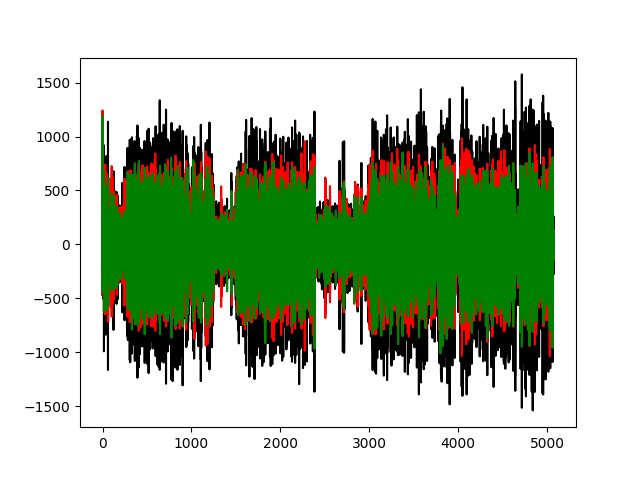

0.039873222097592635
0.059331684849967
0.2266332681215712


In [25]:

ripple_channel_1 = shanks_electrodes[0][0]
ripple_channel_2 = shanks_electrodes[9][0]
ripple_channel_3 = shanks_electrodes[12][0]

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
ripple_phase_1 = np.angle(ripple_hilbert_1)

ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
ripple_phase_2 = np.angle(ripple_hilbert_2)

ripple_lfp_3 = lfp[ripple_channel_3,:].copy()
ripple_filtered_3 = sig.detrend(helper.eegfilt(ripple_lfp_3,srate,100,250))
ripple_hilbert_3 = helper.hilbert(ripple_filtered_3)
ripple_phase_3 = np.angle(ripple_hilbert_3)


ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))
phasediff_1_2 = np.abs(np.nanmean(ripple_phase_diff))

ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_3)))
phasediff_1_3 = np.abs(np.nanmean(ripple_phase_diff))

ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_2)-np.unwrap(ripple_phase_3)))
phasediff_2_3 = np.abs(np.nanmean(ripple_phase_diff))

# plt.figure()
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_1)+20, 'k')
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_2)-20, 'r')
# # plt.xlim([28,30])
# plt.show()


plt.figure()
plt.plot(time_vector, ripple_filtered_1, 'k')
plt.plot(time_vector, ripple_filtered_2, 'r')
plt.plot(time_vector, ripple_filtered_3, 'g')

# plt.xlim([28,30])
plt.show()

print(phasediff_1_2)
print(phasediff_1_3)
print(phasediff_2_3)


In [37]:

max_ripple_channels = []
for channels in shanks_electrodes:
    if len(channels) > 0:
        ripple_lfp = lfp[channels,:]
        ripple_filtered = sig.detrend(helper.eegfilt(ripple_lfp,srate,100,250))
        ripple_hilbert = helper.hilbert(ripple_filtered)
        ripple_amp = np.abs(ripple_hilbert)

        max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
        max_ripple_channels.append(channels[max_ripple_idx])

    else:
        max_ripple_channels.append(np.nan)
max_ripple_channels = np.array(max_ripple_channels)
max_ripple_channels

array([ 1,  6,  9, 13, 17, 23, 26, 30, 32, 36, 42, 44, 50, 53, 59, 61])

In [38]:
ripple_filtered = helper.eegfilt(lfp[max_ripple_channels,:],srate,100,250) 
ripple_amp = np.abs(helper.hilbert(ripple_filtered))


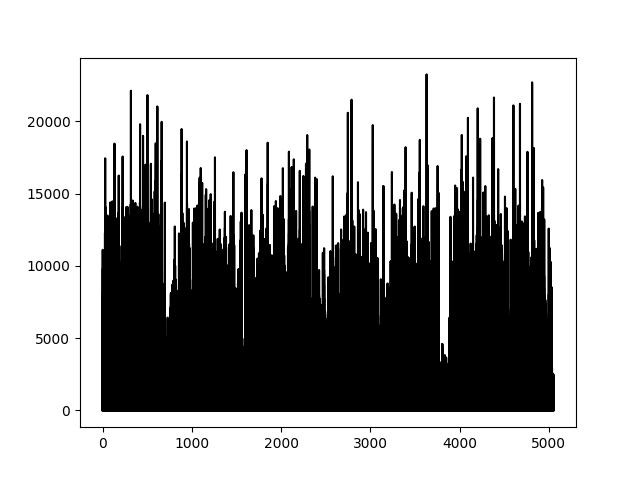

In [39]:

plt.figure()
plt.plot(time_vector, ripple_amp.T, 'k')
plt.show()


In [40]:
mean_ripple_amp = np.nanmean(ripple_amp,0)



In [44]:
import helper_functions as hf
import normalizing_functions as nf
import smoothing_functions as smooth


In [59]:

ripple_features = get_ripple_info_from_envelope(mean_ripple_amp, srate, ripple_threshold_level = 2, min_ripple_duration = 0.01, max_ripple_duration = 0.1, smooth_time = 0.001)



In [60]:
ripple_features.keys()

dict_keys(['centers', 'powers', 'cycles', 'minima', 'max_amplitudes'])

In [61]:
ripple_center_idx = np.array(ripple_features["centers"])

In [65]:

ripple_epoch = np.concatenate(ripple_features["cycles"])


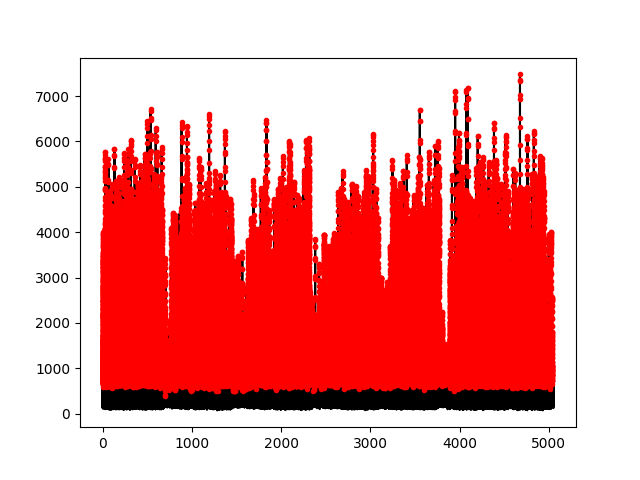

In [88]:
plt.figure()
plt.plot(time_vector, mean_ripple_amp, 'k')
plt.plot(time_vector[ripple_epoch], mean_ripple_amp[ripple_epoch], 'r.')
# plt.xlim([28,30])
plt.show()

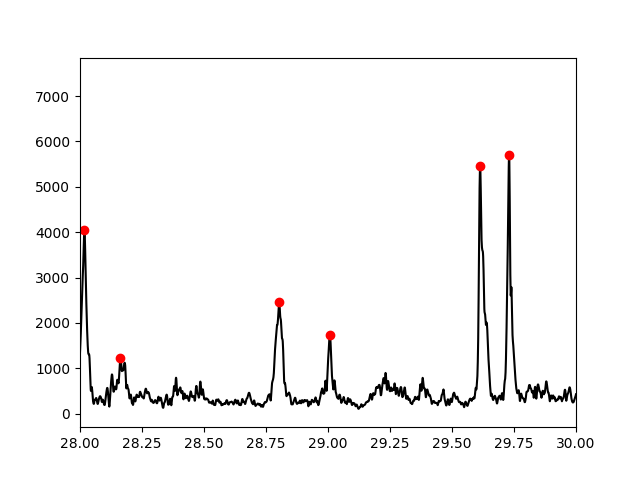

In [63]:

plt.figure()
plt.plot(time_vector, mean_ripple_amp, 'k')
plt.plot(time_vector[ripple_center_idx], mean_ripple_amp[ripple_center_idx], 'ro')
plt.xlim([28,30])
plt.show()


In [97]:
extension_window = 0.05*srate
ripple_epoch_extended = []
for ripple_cycle in ripple_features["cycles"]:
    
    ripple_cycle_start = ripple_cycle[0]
    ripple_cycle_end = ripple_cycle[-1]

    if (ripple_cycle_start-extension_window >= 0) | (ripple_cycle_end+extension_window < lfp.shape[1]):
        ripple_window = np.arange(ripple_cycle_start-extension_window,ripple_cycle_end+extension_window).astype(int)
        ripple_epoch_extended.append(ripple_window)
ripple_epoch_extended = np.concatenate(ripple_epoch_extended)
ripple_epoch_extended

array([    627,     628,     629, ..., 6289118, 6289119, 6289120],
      shape=(861340,))

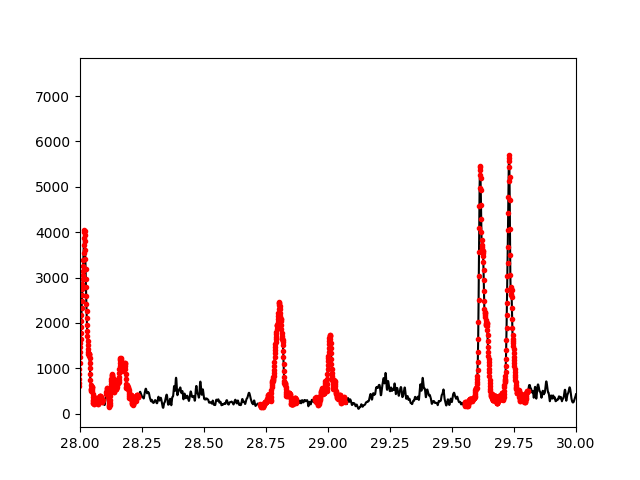

In [98]:

plt.figure()
plt.plot(time_vector, mean_ripple_amp, 'k')
plt.plot(time_vector[ripple_epoch_extended], mean_ripple_amp[ripple_epoch_extended], 'r.')
plt.xlim([28,30])
plt.show()


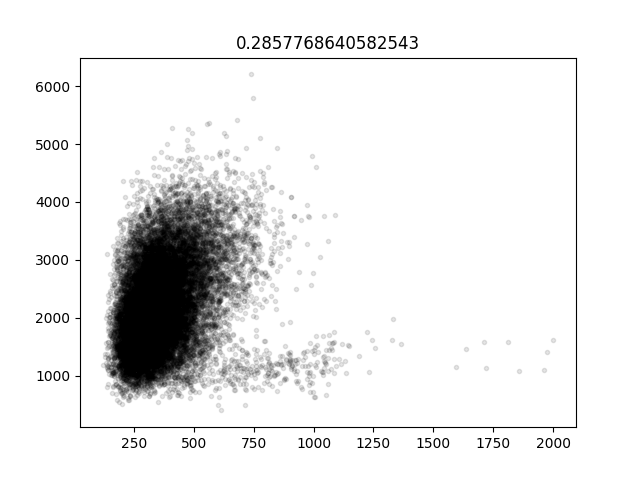

In [99]:

ripple_channel_1 = 1
ripple_channel_2 = 50

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)
ripple_amp_1 = ripple_amp_1[ripple_epoch]

ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)
ripple_amp_2 = ripple_amp_2[ripple_epoch]


# time_vector = np.linspace(0,ripple_epoch.shape[0]/srate,ripple_epoch.shape[0])

amp_window_length = 0.05*srate
non_overlap = 0.01*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []
binned_time_vector = []
for ll in np.arange(0,((ripple_epoch.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    # binned_time_vector.append(np.nanmean(time_vector[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)
# binned_time_vector = np.array(binned_time_vector)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.',alpha=0.1)
plt.title(r_value)
plt.show()



In [109]:
shanks_electrodes

[array([1, 2, 3]),
 array([4, 5, 6, 7]),
 array([ 8,  9, 10, 11]),
 array([12, 13, 14, 15]),
 array([16, 17, 18, 19]),
 array([20, 21, 22, 23]),
 array([25, 26, 27]),
 array([28, 29, 30, 31]),
 array([32, 34, 35]),
 array([36, 37, 38, 39]),
 array([40, 41, 42, 43]),
 array([44, 45, 46, 47]),
 array([48, 49, 50, 51]),
 array([52, 53, 54, 55]),
 array([56, 57, 58, 59]),
 array([60, 61, 62, 63])]

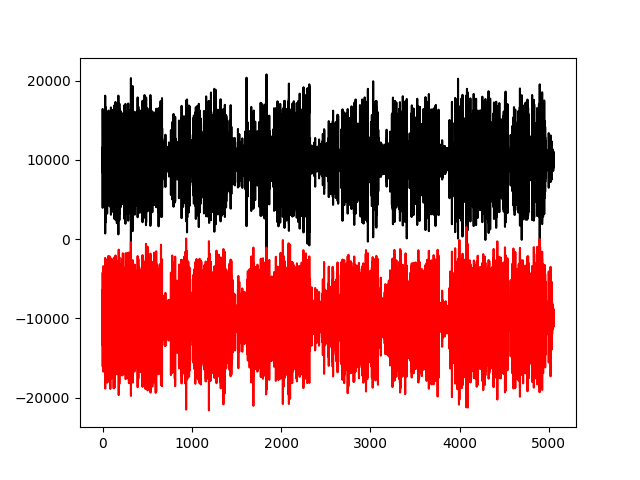

In [128]:

ripple_channel_1 = 20
ripple_channel_2 = 50

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))

# plt.figure()
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_1)+20, 'k')
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_2)-20, 'r')
# # plt.xlim([28,30])
# plt.show()


plt.figure()
plt.plot(time_vector, ripple_filtered_1+10000, 'k')
plt.plot(time_vector, ripple_filtered_2-10000, 'r')
# plt.xlim([28,30])
plt.show()



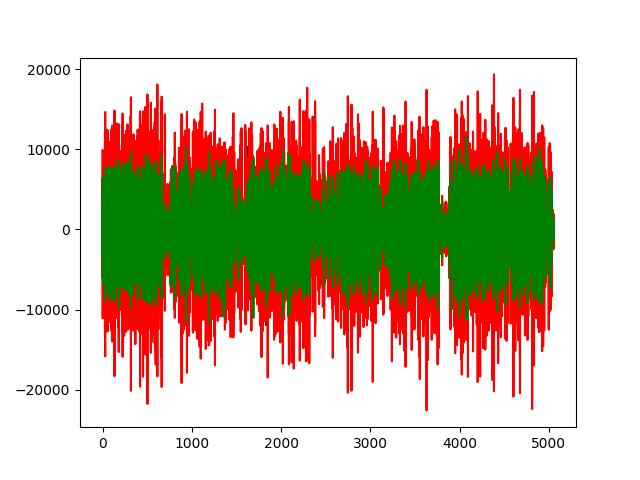

0.03063702054976346
0.019004719530224295
0.28033607970341345


In [3]:

ripple_channel_1 = 20
ripple_channel_2 = 32
ripple_channel_3 = 50

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
ripple_phase_1 = np.angle(ripple_hilbert_1)

ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
ripple_phase_2 = np.angle(ripple_hilbert_2)

ripple_lfp_3 = lfp[ripple_channel_3,:].copy()
ripple_filtered_3 = sig.detrend(helper.eegfilt(ripple_lfp_3,srate,100,250))
ripple_hilbert_3 = helper.hilbert(ripple_filtered_3)
ripple_phase_3 = np.angle(ripple_hilbert_3)


ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))
phasediff_1_2 = np.abs(np.nanmean(ripple_phase_diff))

ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_3)))
phasediff_1_3 = np.abs(np.nanmean(ripple_phase_diff))

ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_2)-np.unwrap(ripple_phase_3)))
phasediff_2_3 = np.abs(np.nanmean(ripple_phase_diff))

# plt.figure()
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_1)+20, 'k')
# plt.plot(time_vector, norm.robust_z_score_norm(ripple_filtered_2)-20, 'r')
# # plt.xlim([28,30])
# plt.show()


plt.figure()
plt.plot(time_vector, ripple_filtered_1, 'k')
plt.plot(time_vector, ripple_filtered_2, 'r')
plt.plot(time_vector, ripple_filtered_3, 'g')

# plt.xlim([28,30])
plt.show()

print(phasediff_1_2)
print(phasediff_1_3)
print(phasediff_2_3)


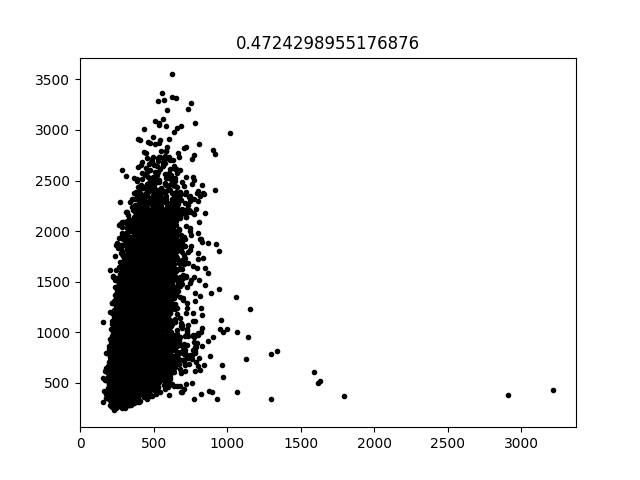

In [122]:

ripple_channel_1 = 28
ripple_channel_2 = 50

ripple_lfp_1 = lfp[ripple_channel_1,:].copy()
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)
ripple_amp_1 = ripple_amp_1[ripple_epoch_extended]

ripple_lfp_2 = lfp[ripple_channel_2,:].copy()
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)
ripple_amp_2 = ripple_amp_2[ripple_epoch_extended]


# time_vector = np.linspace(0,ripple_epoch.shape[0]/srate,ripple_epoch.shape[0])

amp_window_length = 0.1*srate
non_overlap = 0.05*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []
binned_time_vector = []
for ll in np.arange(0,((ripple_epoch_extended.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    # binned_time_vector.append(np.nanmean(time_vector[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)
# binned_time_vector = np.array(binned_time_vector)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.title(r_value)
plt.show()



In [29]:

ripple_channel_1 = 1
ripple_channel_2 = 5

plt.figure()
plt.plot(time_vector, norm.z_score_norm(ripple_1)+20, 'k')
plt.plot(time_vector, norm.z_score_norm(ripple_2)-20, 'r')
plt.show()



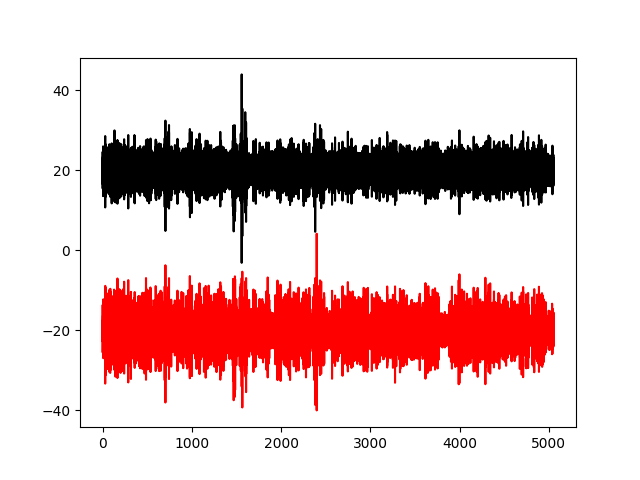

In [32]:

ripple_channel_1 = 1
ripple_channel_2 = 5

ripple_1 = helper.eegfilt(lfp[ripple_channel_1,:],srate,100,250) 
ripple_2 = helper.eegfilt(lfp[ripple_channel_2,:],srate,100,250) 


plt.figure()
plt.plot(time_vector, norm.z_score_norm(ripple_1)+20, 'k')
plt.plot(time_vector, norm.z_score_norm(ripple_2)-20, 'r')
plt.show()



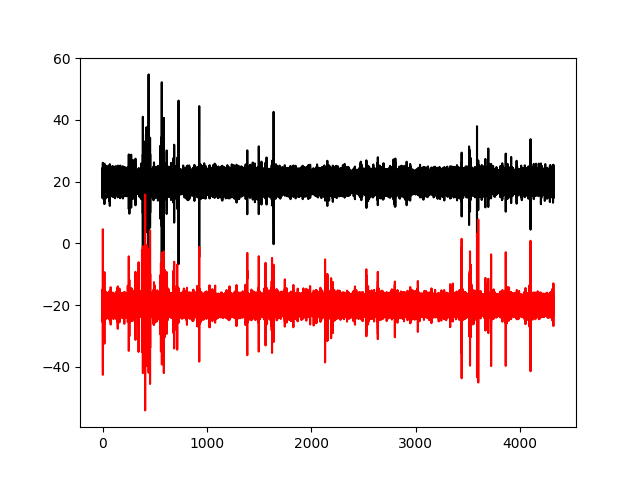

In [36]:
time_vector_sleep = np.linspace(0,sleep_epochs.shape[0]/srate,sleep_epochs.shape[0])

ripple_channel_1 = 1
ripple_channel_2 = 5

ripple_1 = helper.eegfilt(lfp[ripple_channel_1,:][sleep_epochs],srate,100,250) 
ripple_2 = helper.eegfilt(lfp[ripple_channel_2,:][sleep_epochs],srate,100,250) 


plt.figure()
plt.plot(time_vector_sleep, norm.z_score_norm(ripple_1)+20, 'k')
plt.plot(time_vector_sleep, norm.z_score_norm(ripple_2)-20, 'r')
plt.show()



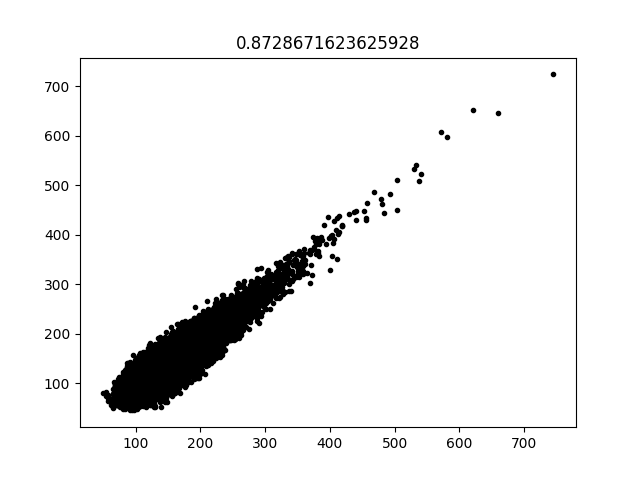

In [24]:

ripple_channel_1 = 1
ripple_channel_2 = 2

ripple_lfp_1 = lfp[int(ripple_channel_1),:]
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)
# ripple_amp_1 = norm.robust_z_score_norm(ripple_amp_1)


ripple_lfp_2 = lfp[int(ripple_channel_2),:]
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)
# ripple_amp_2 = norm.robust_z_score_norm(ripple_amp_2)

time_vector = np.linspace(0,ripple_lfp_1.shape[0]/srate,ripple_lfp_1.shape[0])

amp_window_length = 0.1*srate
non_overlap = 0.05*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []
binned_time_vector = []
for ll in np.arange(0,((ripple_lfp_1.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    binned_time_vector.append(np.nanmean(time_vector[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)
binned_time_vector = np.array(binned_time_vector)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.title(r_value)
plt.show()



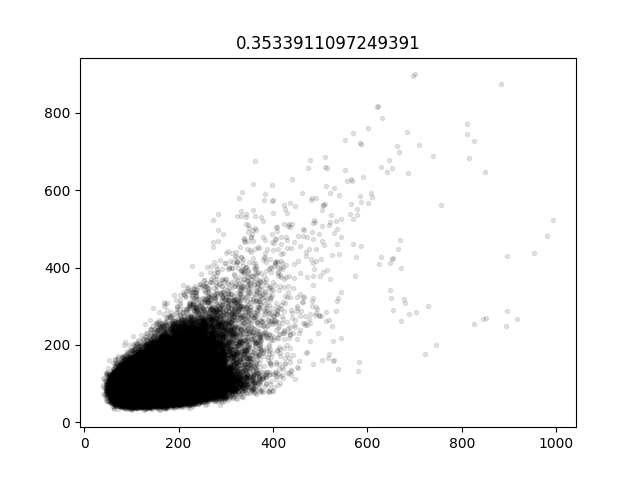

In [23]:
plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.',alpha=0.1)
plt.title(r_value)
plt.show()

In [8]:
ripple_channel_1 = 2
ripple_channel_2 = 48

In [9]:
ripple_features = ripple.get_ripple_info(lfp[ripple_channel_1,:], srate, ripple_band=(100, 250),ripple_threshold_level = 2, 
                                 min_ripple_duration = 0.02, max_ripple_duration = 0.2, smooth_time = 0.005)
    

In [ ]:

ripple_window = np.unique(np.concatenate(ripple_features['cycles']))
lfp_ripple = lfp[:,ripple_window]


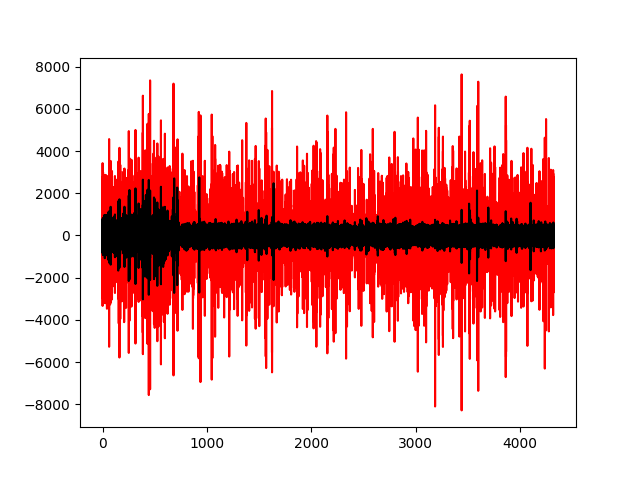

In [37]:
plt.figure()


In [56]:
shanks_electrodes

[array([1, 2, 3]),
 array([4, 5, 6, 7]),
 array([ 8,  9, 10, 11]),
 array([12, 13, 14, 15]),
 array([16, 17, 18, 19]),
 array([20, 21, 22, 23]),
 array([25, 26, 27]),
 array([28, 29, 30, 31]),
 array([32, 34, 35]),
 array([36, 37, 38, 39]),
 array([40, 41, 42, 43]),
 array([44, 45, 46, 47]),
 array([48, 49, 50, 51]),
 array([52, 53, 54, 55]),
 array([56, 57, 58, 59]),
 array([60, 61, 62, 63])]

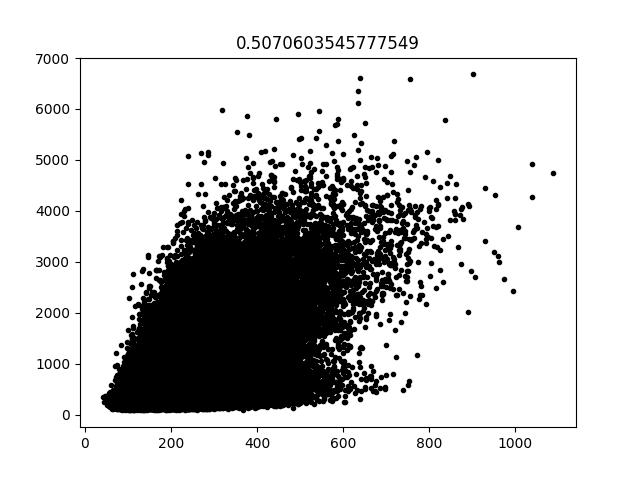

In [71]:

ripple_channel_1 = 2
ripple_channel_2 = 60

ripple_lfp_1 = lfp[int(ripple_channel_1),:]
ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)
# ripple_amp_1 = norm.robust_z_score_norm(ripple_amp_1)


ripple_lfp_2 = lfp[int(ripple_channel_2),:]
ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)
# ripple_amp_2 = norm.robust_z_score_norm(ripple_amp_2)

time_vector = np.linspace(0,ripple_lfp_1.shape[0]/srate,ripple_lfp_1.shape[0])

amp_window_length = 0.05*srate
non_overlap = 0.01*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []
binned_time_vector = []
for ll in np.arange(0,((ripple_lfp_1.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    binned_time_vector.append(np.nanmean(time_vector[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)
binned_time_vector = np.array(binned_time_vector)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.title(r_value)
plt.show()



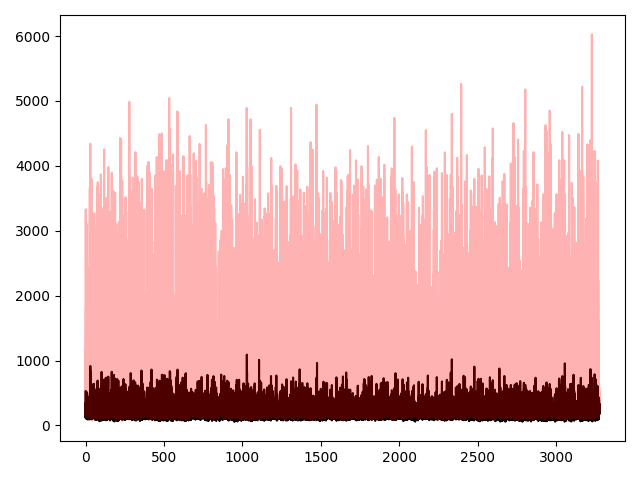

In [57]:

binned_amplitude = (binned_amplitude_1 > 2000) & (binned_amplitude_2 > 2000)

plt.figure()
plt.plot(binned_time_vector, binned_amplitude_1, 'k')
plt.plot(binned_time_vector, binned_amplitude_2, 'r',alpha=0.3)

plt.plot(binned_time_vector[binned_amplitude], binned_amplitude_1[binned_amplitude], 'go')

plt.tight_layout()
plt.show()


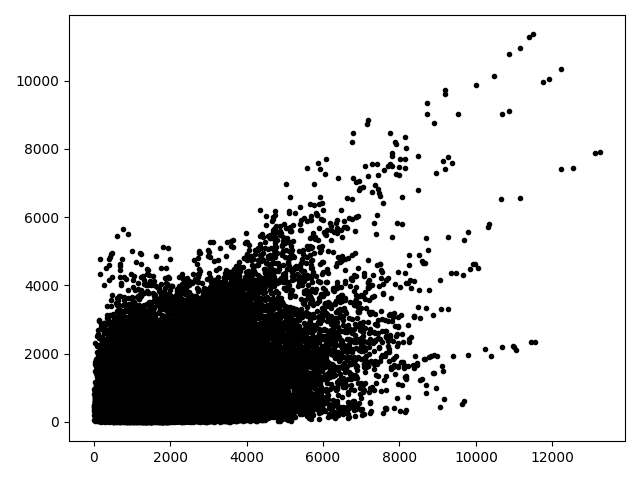

array([[1.        , 0.37082859],
       [0.37082859, 1.        ]])

In [44]:
plt.figure()
plt.plot(ripple_amp_1,ripple_amp_2, 'k.')
plt.tight_layout()
plt.show()
np.corrcoef(ripple_amp_1,ripple_amp_2)

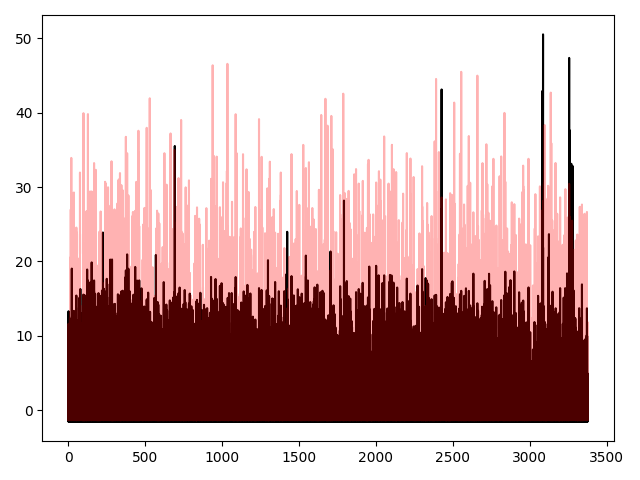

In [19]:

plt.figure()
plt.plot(time_vector, norm.robust_z_score_norm(ripple_amp_1), 'k')
plt.plot(time_vector, norm.robust_z_score_norm(ripple_amp_2), 'r',alpha=0.3)
# plt.plot(binned_time_vector[binned_amplitude], binned_amplitude_1[binned_amplitude], 'go')
plt.tight_layout()
plt.show()


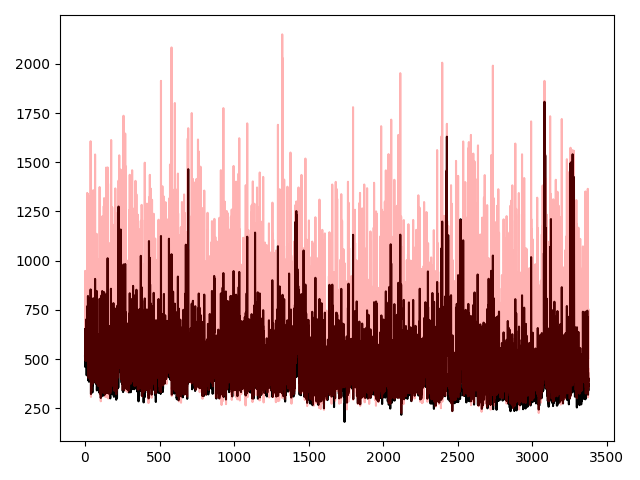

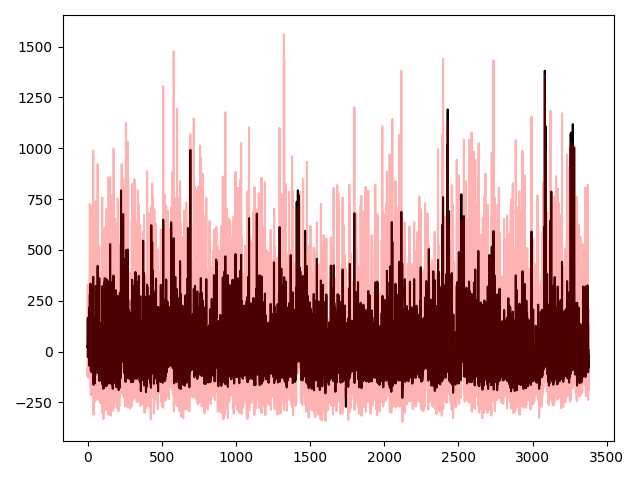

In [8]:

plt.figure()
plt.plot(binned_time_vector, binned_amplitude_1, 'k')
plt.plot(binned_time_vector, binned_amplitude_2, 'r',alpha=0.3)
plt.tight_layout()
plt.show()


# plt.figure()
# plt.plot(binned_time_vector, sig.detrend(binned_amplitude_1), 'k')
# plt.plot(binned_time_vector, sig.detrend(binned_amplitude_2), 'r',alpha=0.3)
# plt.tight_layout()
# plt.show()


In [55]:

time_vector = np.linspace(0,ripple_lfp_1.shape[0]/srate,ripple_lfp_1.shape[0])

amp_window_length = 40*srate
non_overlap = 1*srate
overlap = amp_window_length-non_overlap
binned_correlation = []
for ll in np.arange(0,((ripple_lfp_1.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)
    aux = np.corrcoef(ripple_amp_1[amp_window],ripple_amp_2[amp_window])[0,1]
    binned_correlation.append(aux)
    
binned_correlation = np.array(binned_correlation)
np.nanmean(binned_correlation)


0.35775704130123

0.23241567332990423

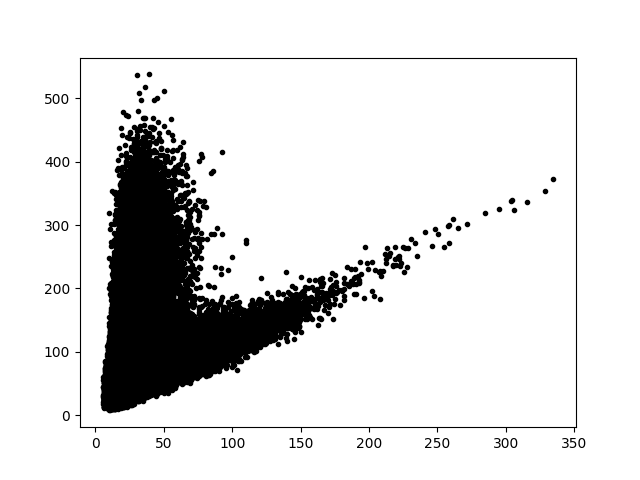

In [58]:
binned_epoch = (binned_time_vector>330) & (binned_time_vector<530)

plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
# plt.plot(binned_amplitude_1[binned_epoch],binned_amplitude_2[binned_epoch],'r.')
plt.show()


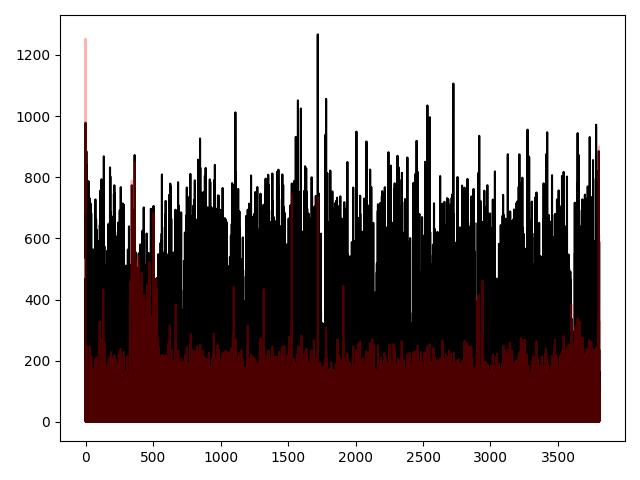

In [82]:

plt.figure()
plt.plot(time_vector, ripple_amp_1, 'k')
plt.plot(time_vector, ripple_amp_2, 'r',alpha=0.3)
plt.tight_layout()
plt.show()


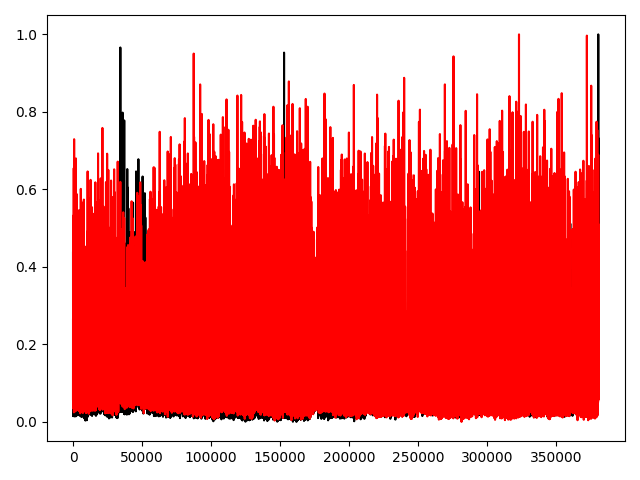

In [15]:

plt.figure()
plt.plot(norm.min_max_norm(binned_amplitude_1), 'k')
plt.plot(norm.min_max_norm(binned_amplitude_2), 'r')
plt.tight_layout()
plt.show()


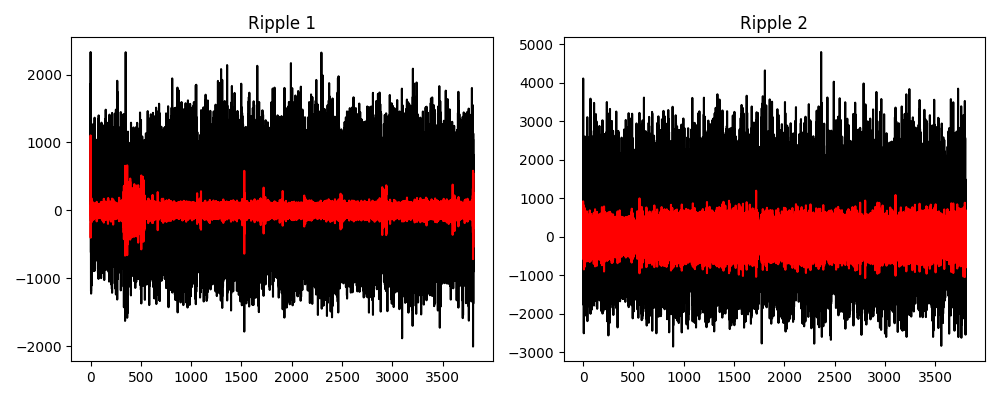

In [24]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))  # create subplots with shared x-axis

axes[0].plot(time_vector, ripple_lfp_1, 'k')
axes[0].plot(time_vector, ripple_filtered_1, 'r')
axes[0].set_title("Ripple 1")

axes[1].plot(time_vector, ripple_lfp_2, 'k')
axes[1].plot(time_vector, ripple_filtered_2, 'r')
axes[1].set_title("Ripple 2")

plt.tight_layout()
plt.show()
